# CMA-ES

In [ ]:
# ! pip install cma "gymnasium[box2d]>=1.0" "stable-baselines3>=2.3"

In [6]:
import numpy as np
import cma
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import gymnasium
import torch
import torch.nn as nn
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from typing import Callable

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam and Momentum.

In [2]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

### Helper functions

Convergence plot and animation.

In [22]:
def plot_convergence(histories: dict[str, list[float]], use_log: bool = False) -> None:
    plt.figure()
    for name, fitness in histories.items():
        plt.plot(fitness, label=name)
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("CMA-ES Convergence")
    plt.legend()
    plt.grid(True)
    if use_log:
        plt.yscale("log")
    plt.show()

def animate_distribution(
    func: Callable[[np.ndarray], float],
    mu_history: list[np.ndarray],
    cov_history: list[np.ndarray],
    bounds: tuple[float, float] = (-5, 5),
    frames: int = 50,
    filename: str = "cma_es_animation.mp4",
) -> None:
    x = np.linspace(bounds[0], bounds[1], 200)
    y = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots()
    levels = np.logspace(np.log10(Z.min() + 1e-6), np.log10(Z.max()), 30)

    def update(frame_index: int) -> None:
        ax.clear()
        ax.contour(X, Y, Z, levels=levels, cmap="viridis")
        mu = mu_history[frame_index]
        cov = cov_history[frame_index]
        vals, vecs = np.linalg.eigh(cov)
        angle = float(np.degrees(np.arctan2(vecs[0, 1], vecs[0, 0])))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            edgecolor="red",
            facecolor="none",
            lw=2,
        )
        ax.add_patch(ellipse)
        ax.plot(mu[0], mu[1], "ro")
        ax.set_title(f"Generation {frame_index}")
        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

    anim = FuncAnimation(fig, update, frames=min(frames, len(mu_history)), interval=200)
    anim.save(filename, writer="ffmpeg")
    print(f"Animation saved to {filename}")

### Running CMA-ES

In [ ]:
from dataclasses import dataclass

@dataclass
class CMAESResult:
    best_fitness: list[float]
    mean_history: list[np.ndarray]
    cov_history: list[np.ndarray]
    sigma_history: list[float]

def run_cma_es(
    func: Callable[[np.ndarray], float],
    x0: np.ndarray,
    sigma0: float,
    max_iterations: int = 100,
    log_every: int = 1
) -> CMAESResult:
    # TODO: Implement this function
    # TODO: Use cma.CMAEvolutionStrategy from pycma: https://pypi.org/project/cma/
    # Hint: Use ask and tell methods
    es = cma.CMAEvolutionStrategy(x0=x0,sigma0=sigma0)

    best_fitness = []
    mean_history = []
    cov_history = []
    sigma_history = []

    for i in range(max_iterations):
        solutions = es.ask()
        fitness_values = [func(x) for x in solutions]

        es.tell(solutions, fitness_values)

        if i % log_every == 0:
            mean_history.append(es.mean.copy())
            cov_history.append(es.C.copy())

        best_fitness.append(es.best.f)
        sigma_history.append(es.sigma)

    return CMAESResult(
        best_fitness=best_fitness,
        mean_history=mean_history,
        cov_history=cov_history,
        sigma_history=sigma_history
    )

### Ex. 1: Impact of the Starting Point
1.	Choose Rosenbrock in 2D.
2.	Run CMA-ES from at least five widely separated initial means (e.g., [-4,-4], [-1,3], [5,5]).
3.	Plot convergence curves and report:
- best fitness vs. generation,
- total evaluations to reach $f(x)\lt10^{-8}$ (or termination).
4.	Briefly discuss sensitivity to the start point. Prepare GIFs for two different starting points.

Hint: use `sigma0 = 0.5` and `max_iter = 250`.

(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1049284, Tue May  5 10:30:52 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1024417, Tue May  5 10:30:52 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=999913, Tue May  5 10:30:52 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1029876, Tue May  5 10:30:52 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1076489, Tue May  5 10:30:52 2026)


/Users/dominik/Desktop/AGH_STUDIES/agh-stochastic-ml/.venv/lib/python3.13/site-packages/cma/utilities/utils.py:369: UserWarning: sigma change np.exp(1.4152613784134067) = 4.117562567303248 clipped to np.exp(+-1) (time=May  5 10:30:52 2026 class=CMAAdaptSigmaCSA method=update iteration=180)
  warnings.warn(msg + ' (time={}'.format(time.asctime()[4:]) +


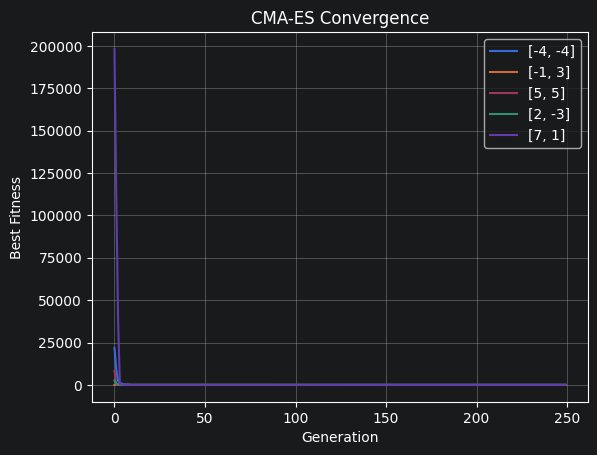

In [11]:
init_means = [
    np.array([-4, -4]),
    np.array([-1, 3]),
    np.array([5, 5]),
    np.array([2, -3]),
    np.array([7, 1]),
]

histories = {}

for x0 in init_means:
    res = run_cma_es(
        func=rosenbrock,
        x0=x0,
        sigma0=0.5,
        max_iterations=250
    )

    key = f"{x0.tolist()}"
    histories[key] = res.best_fitness

plot_convergence(histories, use_log=False)

(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1081366, Tue May  5 10:42:56 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1052961, Tue May  5 10:42:56 2026)
Animation saved to start_-4_-4.mp4
Animation saved to start_-1_3.mp4


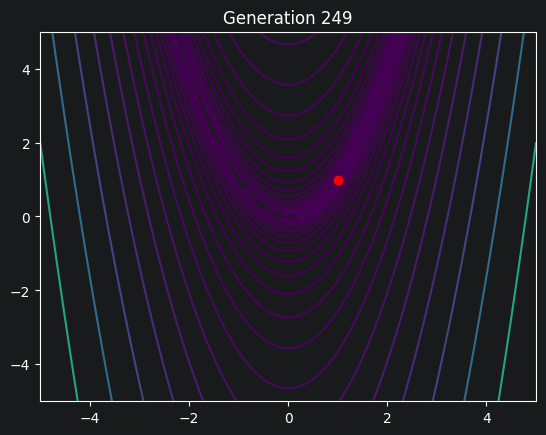

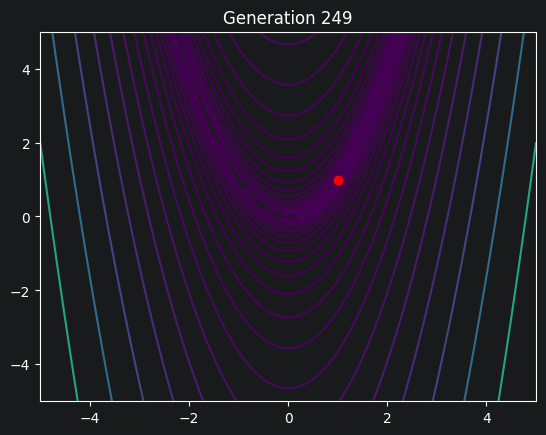

In [23]:
res1 = run_cma_es(
    func=rosenbrock,
    x0=np.array([-4, -4]),
    sigma0=0.5,
    max_iterations=250
)

res2 = run_cma_es(
    func=rosenbrock,
    x0=np.array([-1, 3]),
    sigma0=0.5,
    max_iterations=250
)

animate_distribution(
    func=rosenbrock,
    mu_history=res1.mean_history,
    cov_history=res1.cov_history,
    frames=250,
    filename="start_-4_-4.mp4"
)

animate_distribution(
    func=rosenbrock,
    mu_history=res2.mean_history,
    cov_history=res2.cov_history,
    frames=250,
    filename="start_-1_3.mp4"
)

### Ex. 2: Effect of the Initial Global Step‐Size $\sigma_0$
1. Use [2,2] at starting point on the Rastrigin function.
2. Test $\sigma_0\in\{0.1,\,0.5,\,1,\,2,\,5\}$.
3. Record and plot
- final fitness after a fixed budget (e.g. 1000 evals)
- evolution of es.sigma over time (log scale).
4. Explain why too-small and too-large $\sigma_0$ hurt performance, relating findings to the adaptation rule.

(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1116188, Tue May  5 10:29:11 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1117854, Tue May  5 10:29:11 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1109213, Tue May  5 10:29:11 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1131092, Tue May  5 10:29:11 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1111075, Tue May  5 10:29:11 2026)


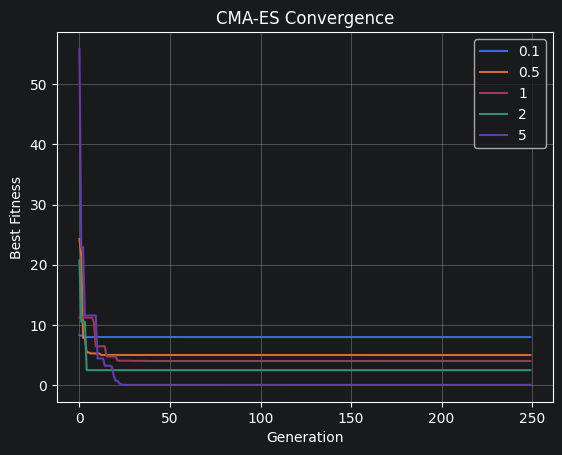

In [8]:
x0 = np.array([2, 2])
sigmas = [0.1, 0.5, 1, 2, 5]

hist = {}
for sigma in sigmas:
    res = run_cma_es(
        func=rastrigin,
        x0=x0,
        sigma0=sigma,
        max_iterations=250
    )

    key = f"{sigma}"
    hist[key] = res.best_fitness

plot_convergence(hist)



(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1151647, Tue May  5 10:43:59 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1152082, Tue May  5 10:43:59 2026)
Animation saved to sigma_2_.mp4
Animation saved to sigma_01.mp4


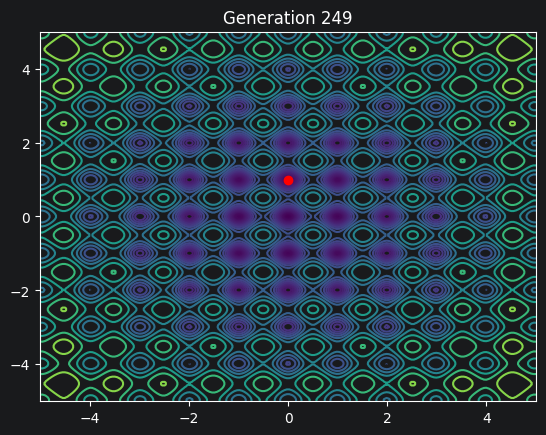

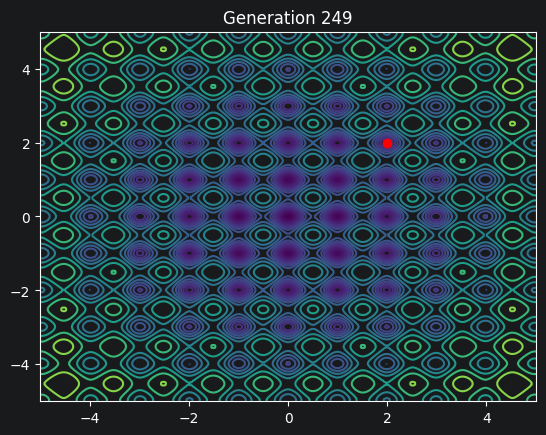

In [24]:
res3 = run_cma_es(
    func=rastrigin,
    x0=np.array([2, 2]),
    sigma0=2,
    max_iterations=250
)

res4 = run_cma_es(
    func=rastrigin,
    x0=np.array([2, 2]),
    sigma0=0.1,
    max_iterations=250
)

animate_distribution(
    func=rastrigin,
    mu_history=res3.mean_history,
    cov_history=res3.cov_history,
    frames=250,
    filename="sigma_2_.mp4"
)

animate_distribution(
    func=rastrigin,
    mu_history=res4.mean_history,
    cov_history=res4.cov_history,
    frames=250,
    filename="sigma_01.mp4"
)

### Ex. 3: Visualising the Covariance Matrix Adaptation
1. On Rastrigin (and Sphere) in 2D, log es.C every 5 generations.
2. Use the provided `animate_distribution` to produce a GIF showing the shrinking and rotation of the sampling ellipse.
3. Submit the animation and two short observations about what the animation reveals regarding step-size vs. shape adaptation.

(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1011605, Tue May  5 10:44:27 2026)
(3_w,6)-aCMA-ES (mu_w=2.0,w_1=63%) in dimension 2 (seed=1046135, Tue May  5 10:44:27 2026)
Animation saved to rastrigin.mp4
Animation saved to sphere.mp4


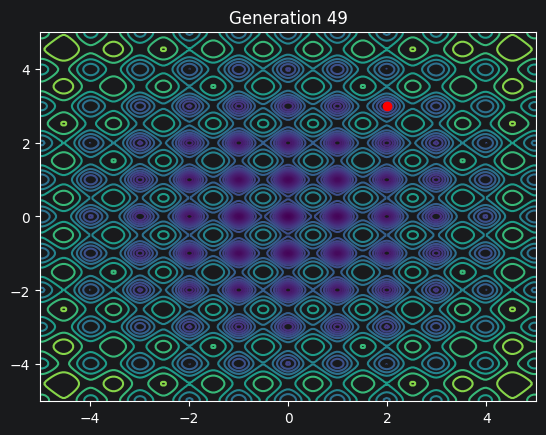

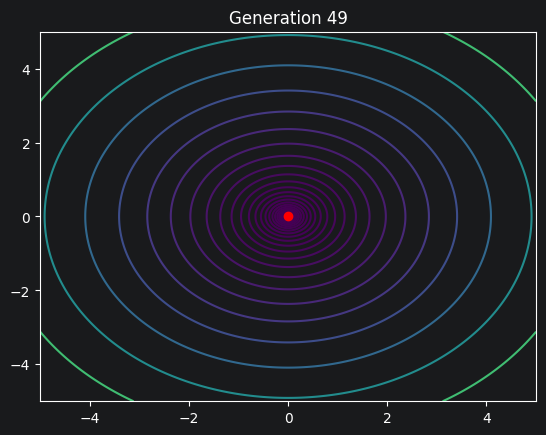

In [25]:
res_rastrigin = run_cma_es(func=rastrigin, x0=np.array([3, 3]), sigma0=0.5, max_iterations=250, log_every=5)
res_sphere = run_cma_es(func=sphere, x0=np.array([3, 3]), sigma0=0.5, max_iterations=250, log_every=5)

animate_distribution(
    func=rastrigin,
    mu_history=res_rastrigin.mean_history,
    cov_history=res_rastrigin.cov_history,
    filename="rastrigin.mp4"
)

animate_distribution(
    func=sphere,
    mu_history=res_sphere.mean_history,
    cov_history=res_sphere.cov_history,
    filename="sphere.mp4"
)

## Part 2: CMA-ES for Reinforcement Learning

So far we have tested CMA-ES on synthetic benchmark functions where we know the true optimum. Now we apply it to a real control task: **LunarLander-v3**.

### The environment
LunarLander-v3 (Box2D) is a classic RL benchmark:
- **Observation**: 8-D continuous vector (lander position, velocity, angle, angular velocity, leg contact flags).
- **Action**: 4 discrete actions (do nothing, fire left engine, fire main engine, fire right engine).
- **Reward**: dense — shaped by distance to landing pad, fuel used, crash/landing bonus.

### Why this problem?
LunarLander with an MLP policy has ~200 parameters, which is:
- large enough that the covariance matrix has real work to do,
- small enough that CMA-ES fits in a few minutes on a laptop,
- non-differentiable end-to-end (argmax over discrete actions), so gradient-based methods cannot be applied naively.

### Policy architecture
A tiny MLP with tanh activations: 8 → 16 → 4 logits, argmax for action selection. Total parameters: `8*16 + 16 + 16*4 + 4 = 212`. We flatten all weights and biases into a single vector `θ ∈ ℝ²¹²` so CMA-ES can treat the whole policy as a point in parameter space.

In [7]:
ENV_NAME: str = "LunarLander-v3"
OBS_DIM: int = 8
ACT_DIM: int = 4
HIDDEN: int = 16
N_PARAMS: int = OBS_DIM * HIDDEN + HIDDEN + HIDDEN * ACT_DIM + ACT_DIM


class MLPPolicy(nn.Module):
    """Tiny MLP: obs -> hidden (tanh) -> logits -> argmax action."""

    def __init__(self, obs_dim: int = OBS_DIM, hidden: int = HIDDEN, act_dim: int = ACT_DIM) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)

    @torch.no_grad()
    def act(self, obs: np.ndarray) -> int:
        logits = self.forward(torch.as_tensor(obs, dtype=torch.float32))
        return int(torch.argmax(logits).item())


def set_params(policy: MLPPolicy, flat: np.ndarray) -> None:
    """Copy a flat parameter vector into the policy's weights/biases."""
    assert flat.shape == (N_PARAMS,), f"expected {N_PARAMS} params, got {flat.shape}"
    offset = 0
    for p in policy.parameters():
        n = p.numel()
        p.data.copy_(torch.as_tensor(flat[offset : offset + n], dtype=torch.float32).view_as(p))
        offset += n


def get_params(policy: MLPPolicy) -> np.ndarray:
    """Flatten the policy's weights/biases into a single vector."""
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in policy.parameters()])


def rollout(policy: MLPPolicy, env: gymnasium.Env, seed: int | None = None) -> tuple[float, int]:
    """Run one episode; return (total reward, number of env steps)."""
    obs, _ = env.reset(seed=seed)
    total = 0.0
    steps = 0
    terminated = truncated = False
    while not (terminated or truncated):
        action = policy.act(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total += float(reward)
        steps += 1
    return total, steps


def evaluate_policy(
    flat_params: np.ndarray,
    env: gymnasium.Env,
    policy: MLPPolicy,
    n_episodes: int = 3,
    base_seed: int = 0,
) -> tuple[float, int]:
    """Average reward over `n_episodes` with fixed episode seeds (common random numbers).

    Using the same seeds across candidates reduces the noise in pairwise comparisons
    between policies — an antithetic / CRN variance-reduction trick."""
    set_params(policy, flat_params)
    rewards: list[float] = []
    total_steps = 0
    for i in range(n_episodes):
        r, s = rollout(policy, env, seed=base_seed + i)
        rewards.append(r)
        total_steps += s
    return float(np.mean(rewards)), total_steps

### Shared budget

To make the comparison against baselines in Ex. 6 fair, we cap every method at the same number of *environment steps*. This is the currency that matters in RL — wall-clock varies by implementation, but env-steps are identical across methods.

In [8]:
BUDGET_STEPS: int = 500_000
EPISODES_PER_EVAL: int = 3
POPSIZE: int = 16
SIGMA0_RL: float = 0.5

### Ex. 4: Train LunarLander with CMA-ES

1. Create a `MLPPolicy` and a single persistent `gymnasium.make(ENV_NAME)` environment.
2. Write `train_cma_es_rl(...)` that uses `cma.CMAEvolutionStrategy` (ask/tell loop) to **maximize** `evaluate_policy(θ)`. Remember CMA-ES minimizes — negate the reward.
3. Stop when cumulative env-steps exceed `BUDGET_STEPS`.
4. Per generation, record: mean reward of the population, best-so-far reward, cumulative env-steps.
5. Return a dict: `{"steps": [...], "best": [...], "mean": [...], "best_params": np.ndarray}`. We'll reuse this structure for all methods in Ex. 5.
6. Plot reward vs. cumulative env-steps. Render one final rollout with `gymnasium.make(ENV_NAME, render_mode="human")` to see the learned behaviour.

**Hints**
- `popsize=POPSIZE`, `sigma0=SIGMA0_RL`, `x0=np.zeros(N_PARAMS)`.
- `cma.CMAEvolutionStrategy(x0, sigma0, {"popsize": POPSIZE, "verbose": -9})`.
- Use `EPISODES_PER_EVAL` episodes per candidate with the *same* base_seed across the whole population in one generation (CRN). Bump the base_seed each generation so CMA-ES doesn't overfit to three fixed seeds.

In [11]:
# TODO: implement train_cma_es_rl and run it here.
# Expected return shape: dict(steps=list[int], best=list[float], mean=list[float], best_params=np.ndarray)



def train_cma_es_rl(
    env: gymnasium.Env,
    policy: MLPPolicy,
    budget_steps: int = BUDGET_STEPS,
    popsize: int = POPSIZE,
    sigma0: float = SIGMA0_RL,
    episodes_per_eval: int = EPISODES_PER_EVAL,
    seed: int = 0,
) -> dict:
    x0 = np.zeros(N_PARAMS, dtype=np.float64)

    es = cma.CMAEvolutionStrategy(
        x0,
        sigma0,
        {
            "popsize": popsize,
            "verbose": -9,
            "seed": seed,
        },
    )

    steps_history = []
    best_history = []
    mean_history = []

    total_steps = 0
    best_reward = -np.inf
    best_params = x0.copy()

    generation = 0

    while total_steps < budget_steps:
        solutions = es.ask()

        fitnesses = []
        rewards = []

        base_seed = seed + generation * 1000

        for theta in solutions:
            reward, used_steps = evaluate_policy(
                flat_params=np.asarray(theta),
                env=env,
                policy=policy,
                n_episodes=episodes_per_eval,
                base_seed=base_seed,
            )

            total_steps += used_steps

            fitnesses.append(-reward)
            rewards.append(reward)

            if reward > best_reward:
                best_reward = reward
                best_params = np.asarray(theta).copy()

            if total_steps >= budget_steps:
                break

        evaluated_solutions = solutions[: len(fitnesses)]
        es.tell(evaluated_solutions, fitnesses)

        mean_reward = float(np.mean(rewards))

        steps_history.append(total_steps)
        best_history.append(float(best_reward))
        mean_history.append(mean_reward)

        print(
            f"gen={generation:03d} "
            f"steps={total_steps:07d} "
            f"mean={mean_reward:8.2f} "
            f"best={best_reward:8.2f}"
        )

        generation += 1

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": best_params,
    }

In [12]:
env = gymnasium.make(ENV_NAME)
policy = MLPPolicy()

cma_es_result = train_cma_es_rl(
    env=env,
    policy=policy,
    budget_steps=BUDGET_STEPS,
    popsize=POPSIZE,
    sigma0=SIGMA0_RL,
    episodes_per_eval=EPISODES_PER_EVAL,
    seed=0,
)

env.close()

gen=000 steps=0004688 mean= -597.77 best=  -85.66
gen=001 steps=0010891 mean= -804.67 best=  -85.66
gen=002 steps=0014681 mean= -357.71 best=  -85.66
gen=003 steps=0018804 mean= -444.99 best=  -85.66
gen=004 steps=0023117 mean= -377.78 best=  -85.66
gen=005 steps=0026809 mean= -150.85 best=  -33.95
gen=006 steps=0030291 mean= -195.59 best=  -33.95
gen=007 steps=0033437 mean= -165.97 best=  -33.95
gen=008 steps=0036656 mean= -174.73 best=  -33.95
gen=009 steps=0040973 mean= -180.57 best=  -33.95
gen=010 steps=0044710 mean= -120.32 best=  -33.95
gen=011 steps=0048638 mean=  -89.79 best=   10.53
gen=012 steps=0053162 mean= -241.05 best=   10.53
gen=013 steps=0057317 mean= -133.61 best=   10.53
gen=014 steps=0062355 mean= -128.15 best=   19.90
gen=015 steps=0067005 mean= -243.71 best=   19.90
gen=016 steps=0072825 mean= -186.77 best=   19.90
gen=017 steps=0077131 mean= -161.80 best=   19.90
gen=018 steps=0080590 mean= -197.43 best=   19.90
gen=019 steps=0084783 mean= -135.11 best=   37.40


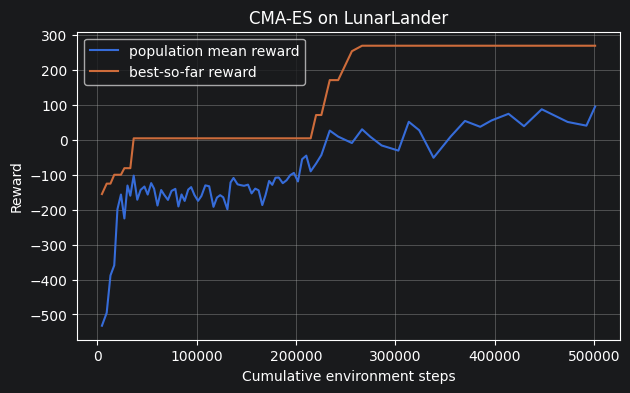

In [38]:
plt.figure(figsize=(7, 4))
plt.plot(cma_es_result["steps"], cma_es_result["mean"], label="population mean reward")
plt.plot(cma_es_result["steps"], cma_es_result["best"], label="best-so-far reward")
plt.xlabel("Cumulative environment steps")
plt.ylabel("Reward")
plt.title("CMA-ES on LunarLander")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
render_env = gymnasium.make(ENV_NAME, render_mode="human")

best_policy = MLPPolicy()
set_params(best_policy, cma_es_result["best_params"])

reward, steps = rollout(best_policy, render_env, seed=123)

print(f"Final rollout reward: {reward:.2f}, steps: {steps}")

render_env.close()

Final rollout reward: 288.17, steps: 216


### Ex. 5: Baselines — is CMA-ES actually doing something clever?

CMA-ES shows nice-looking learning curves, but before we credit the *covariance adaptation* we need a baseline. Two questions:

- **Does search matter at all?** → compare to **random search**: sample i.i.d. Gaussian parameter vectors, keep the best. Same evaluation protocol, same env-step budget.
- **Does being an RL algorithm matter?** → compare to **PPO** from Stable-Baselines3, a standard on-policy actor-critic method. Same env, same env-step budget.

Plot all three on a single chart: *best-so-far reward* (y) vs. *cumulative env-steps* (x). That is the only fair axis — not generations, not wall-clock.

#### Ex. 5a: Random search baseline

Implement `train_random_search(...)` that draws candidates from $\mathcal{N}(0, \sigma_0^2 I)$ and keeps the best, using `evaluate_policy` and `BUDGET_STEPS`. Return the same dict format as `train_cma_es_rl`.

In [33]:
def train_random_search(
    env: gymnasium.Env,
    policy: MLPPolicy,
    budget_steps: int = BUDGET_STEPS,
    sigma0: float = SIGMA0_RL,
    episodes_per_eval: int = EPISODES_PER_EVAL,
    seed: int = 0,
) -> dict:
    rng = np.random.default_rng(seed)

    steps_history = []
    best_history = []
    mean_history = []

    total_steps = 0
    best_reward = -np.inf
    best_params = np.zeros(N_PARAMS, dtype=np.float64)

    generation = 0

    while total_steps < budget_steps:
        theta = rng.normal(
            loc=0.0,
            scale=sigma0,
            size=N_PARAMS,
        ).astype(np.float64)

        base_seed = seed + generation * 1000

        reward, used_steps = evaluate_policy(
            flat_params=theta,
            env=env,
            policy=policy,
            n_episodes=episodes_per_eval,
            base_seed=base_seed,
        )

        total_steps += used_steps

        if reward > best_reward:
            best_reward = reward
            best_params = theta.copy()

        steps_history.append(total_steps)
        best_history.append(float(best_reward))
        mean_history.append(float(reward))

        print(
            f"iter={generation:04d} "
            f"steps={total_steps:07d} "
            f"reward={reward:8.2f} "
            f"best={best_reward:8.2f}"
        )

        generation += 1

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": best_params,
    }

In [34]:
env = gymnasium.make(ENV_NAME)
policy = MLPPolicy()

random_result = train_random_search(
    env=env,
    policy=policy,
    budget_steps=BUDGET_STEPS,
    sigma0=SIGMA0_RL,
    episodes_per_eval=EPISODES_PER_EVAL,
    seed=0,
)

env.close()

iter=0000 steps=0000244 reward=  -85.25 best=  -85.25
iter=0001 steps=0000620 reward= -789.98 best=  -85.25
iter=0002 steps=0000883 reward= -387.47 best=  -85.25
iter=0003 steps=0001102 reward= -665.10 best=  -85.25
iter=0004 steps=0001518 reward=-1085.85 best=  -85.25
iter=0005 steps=0001736 reward= -556.73 best=  -85.25
iter=0006 steps=0001960 reward= -410.39 best=  -85.25
iter=0007 steps=0002301 reward= -684.00 best=  -85.25
iter=0008 steps=0002480 reward= -135.74 best=  -85.25
iter=0009 steps=0002670 reward= -563.08 best=  -85.25
iter=0010 steps=0002896 reward= -434.09 best=  -85.25
iter=0011 steps=0003107 reward= -105.87 best=  -85.25
iter=0012 steps=0003357 reward= -133.01 best=  -85.25
iter=0013 steps=0003574 reward= -163.87 best=  -85.25
iter=0014 steps=0003793 reward= -106.89 best=  -85.25
iter=0015 steps=0003975 reward= -131.86 best=  -85.25
iter=0016 steps=0004186 reward= -410.51 best=  -85.25
iter=0017 steps=0004420 reward= -398.91 best=  -85.25
iter=0018 steps=0004598 rewa

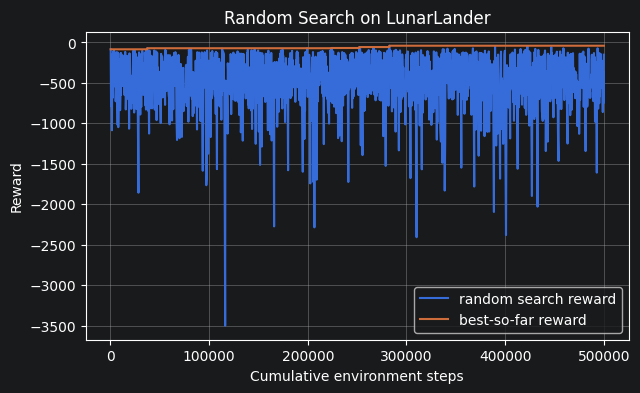

In [35]:
plt.figure(figsize=(7, 4))
plt.plot(random_result["steps"], random_result["mean"], label="random search reward")
plt.plot(random_result["steps"], random_result["best"], label="best-so-far reward")
plt.xlabel("Cumulative environment steps")
plt.ylabel("Reward")
plt.title("Random Search on LunarLander")
plt.legend()
plt.grid(True)
plt.show()

#### Ex. 5b: PPO baseline (Stable-Baselines3)

PPO is a policy-gradient method; it trains by sampling actions stochastically, computing advantages, and taking gradient steps on a clipped surrogate objective. It requires a *differentiable* stochastic policy — so SB3 uses its own MLP underneath, with a softmax over actions and an independent value head.

Install once: `pip install stable-baselines3`.

In [36]:
import tempfile
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor


def train_ppo(total_steps: int = BUDGET_STEPS, eval_freq: int = 5_000, seed: int = 0) -> dict:
    """Train PPO on LunarLander-v3. Requires stable-baselines3 >= 2.0 (native Gymnasium support).

    Note: `EvalCallback` only populates `evaluations_timesteps` / `evaluations_results`
    when `log_path` is set — otherwise they remain empty lists. We use a tempdir.
    """
    train_env = Monitor(gymnasium.make(ENV_NAME))
    eval_env = Monitor(gymnasium.make(ENV_NAME))
    log_dir = tempfile.mkdtemp(prefix="ppo_eval_")
    model = PPO(
        "MlpPolicy", 
        train_env,
        policy_kwargs=dict(net_arch=[HIDDEN]),
        learning_rate=3e-4, 
        n_steps=1024, 
        batch_size=64, 
        n_epochs=4,
        gamma=0.99, 
        gae_lambda=0.95, 
        clip_range=0.2,
        verbose=0, 
        seed=seed,
    )
    callback = EvalCallback(
        eval_env, n_eval_episodes=EPISODES_PER_EVAL,
        eval_freq=eval_freq, deterministic=True, verbose=0,
        log_path=log_dir,
    )
    model.learn(total_timesteps=total_steps, callback=callback)
    steps = list(callback.evaluations_timesteps)
    mean_rewards = [float(np.mean(r)) for r in callback.evaluations_results]
    best_so_far: list[float] = []; running = -np.inf
    for r in mean_rewards:
        running = max(running, r); best_so_far.append(running)
    train_env.close(); eval_env.close()
    return {"steps": steps, "best": best_so_far, "mean": mean_rewards, "model": model}

ppo_result = train_ppo()
print(f"PPO collected {len(ppo_result['steps'])} evaluation points")

PPO collected 100 evaluation points


#### Ex. 5c: Compare all three

Plot best-so-far reward vs. cumulative env-steps for CMA-ES, Random Search, and PPO on the same chart. Add a horizontal line at reward = 200 (the "solved" threshold).

Then answer in 3–5 sentences:
1. Did CMA-ES beat Random Search? If yes — what did the covariance adaptation buy us?
2. How does CMA-ES compare to PPO at the same env-step budget?
3. In what sense is the comparison *unfair* in each direction? (Think: hyperparameter count, bootstrapping in PPO, env-step definition, wall-clock.)

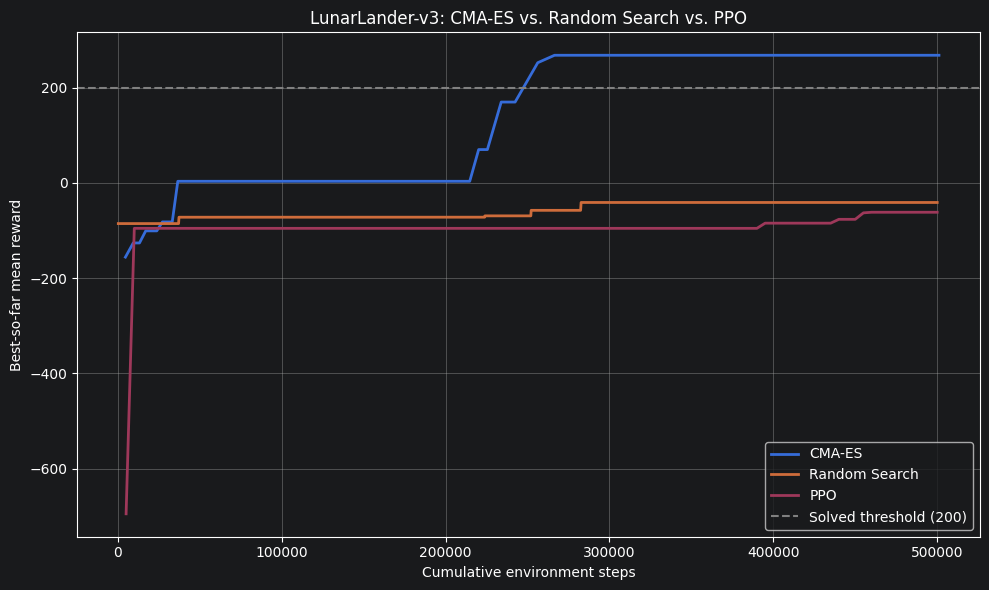

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(cma_es_result["steps"], cma_es_result["best"], label="CMA-ES", linewidth=2)
plt.plot(random_result["steps"], random_result["best"], label="Random Search", linewidth=2)
plt.plot(ppo_result["steps"],   ppo_result["best"],   label="PPO", linewidth=2)
plt.axhline(200, color="gray", linestyle="--", label="Solved threshold (200)")
plt.xlabel("Cumulative environment steps")
plt.ylabel("Best-so-far mean reward")
plt.title("LunarLander-v3: CMA-ES vs. Random Search vs. PPO")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Yes, CMA-ES clearly beat Random Search: it reached rewards above the solved threshold of 200, while Random Search stayed far below zero. The covariance adaptation helped CMA-ES learn promising directions in parameter space instead of sampling candidates independently from a fixed isotropic Gaussian.

At the same environment-step budget, CMA-ES also outperformed PPO in this experiment, reaching a much higher best-so-far reward. PPO improved only slightly and remained negative, while CMA-ES eventually found a successful policy.

However, the comparison is not completely fair. CMA-ES has fewer algorithmic components but evaluates many full policies and can be expensive in wall-clock time, while PPO uses gradient-based updates, bootstrapping, and more hyperparameters. The env-step accounting may also differ: PPO reuses collected data for several optimization epochs, whereas CMA-ES only uses rewards from complete rollouts, so equal environment steps do not necessarily mean equal computation.

### When is CMA-ES a good fit?


**When to reach for CMA-ES in practice**: black-box or non-differentiable objective; small-to-medium parameter count (up to a few thousand); reward signal is noisy; you have parallel compute; you do not want to tune many hyperparameters. Classic applications: controller tuning, hyperparameter optimization, evolving neural network weights for control tasks, direct optimization of simulator-based designs.

In [13]:
# Watch the trained CMA-ES policy (optional — requires a display)
render_env = gymnasium.make(ENV_NAME, render_mode="human")
policy = MLPPolicy(); set_params(policy, cma_es_result["best_params"])
for i in range(3):
    r, _ = rollout(policy, render_env, seed=10_000 + i)
    print(f"Episode {i}: reward={r:.1f}")
render_env.close()

Episode 0: reward=-294.8
Episode 1: reward=-319.2
Episode 2: reward=-244.3
